In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

In [2]:
df = pd.read_excel("default of credit card clients.xls", header=1)

df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [3]:
# rename target column
df.rename(columns={'default payment next month': 'default'}, inplace=True)

# drop ID column
df.drop('ID', axis=1, inplace=True)

# check missing values
print(df.isnull().sum())

# basic info
df.info()

LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
default      0
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   LIMIT_BAL  30000 non-null  int64
 1   SEX        30000 non-null  int64
 2   EDUCATION  30000 non-null  int64
 3   MARRIAGE   30000 non-null  int64
 4   AGE        30000 non-null  int64
 5   PAY_0      30000 non-null  int64
 6   PAY_2      30000 non-null  int64
 7   PAY_3      30000 non-null  int64
 8   PAY_4      30000 non-null  int64
 9   PAY_5      30000 non-null  int64
 10  PAY_6      30000 non-null  int64
 11  BILL_AMT1  30000 non-null  int

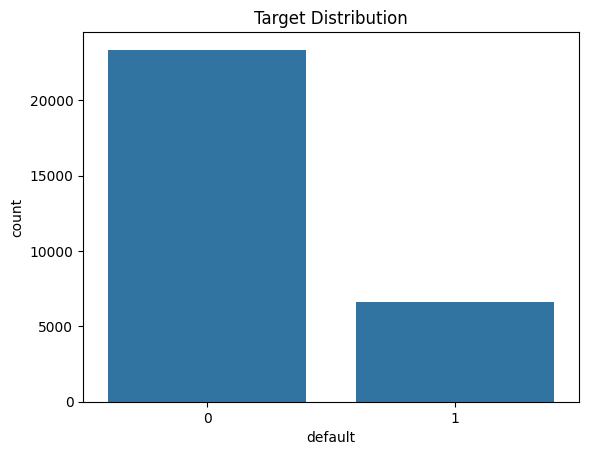

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [4]:
# target distribution
sns.countplot(x='default', data=df)
plt.title("Target Distribution")
plt.show()

# summary statistics
df.describe()

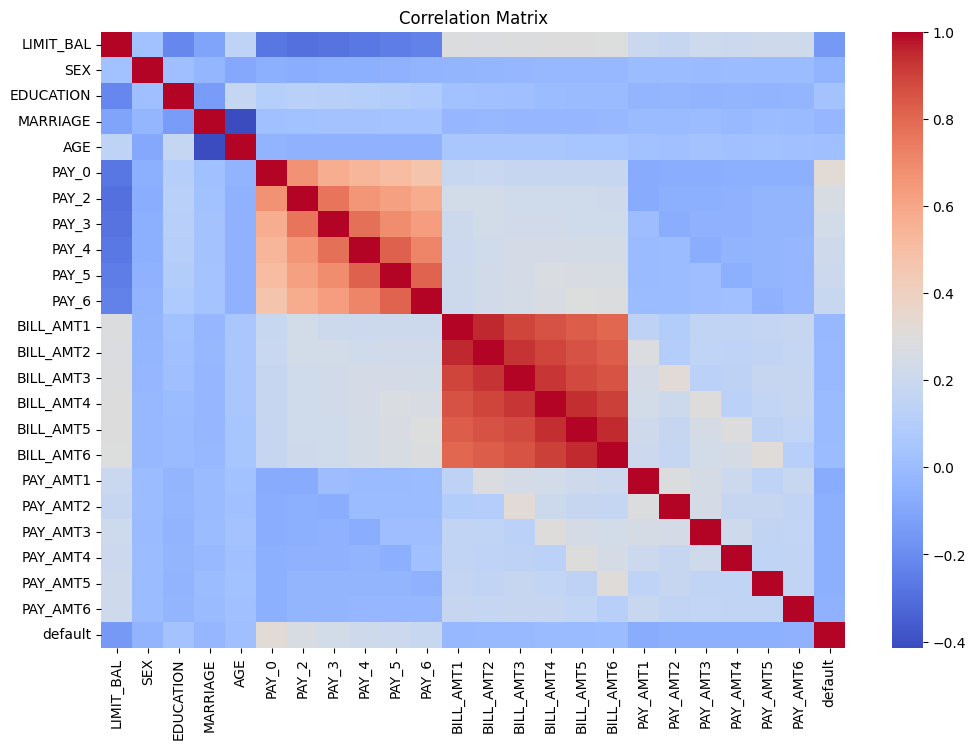

In [5]:
# correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [6]:
# fix EDUCATION categories
df['EDUCATION'] = df['EDUCATION'].replace([0, 5, 6], 4)

# fix MARRIAGE categories
df['MARRIAGE'] = df['MARRIAGE'].replace(0, 3)

In [7]:
# split features and target
X = df.drop('default', axis=1)
y = df['default']

In [8]:
# split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
from sklearn.preprocessing import StandardScaler

# initialize scaler
scaler = StandardScaler()

# fit on train, transform both
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
# initialize model
model = LogisticRegression(max_iter=1000)

# train model
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [11]:
# predictions
y_pred = model.predict(X_test)

# probabilities
y_prob = model.predict_proba(X_test)[:,1]

In [12]:
# accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# ROC AUC
print("ROC AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.81
ROC AUC: 0.7270980597920289


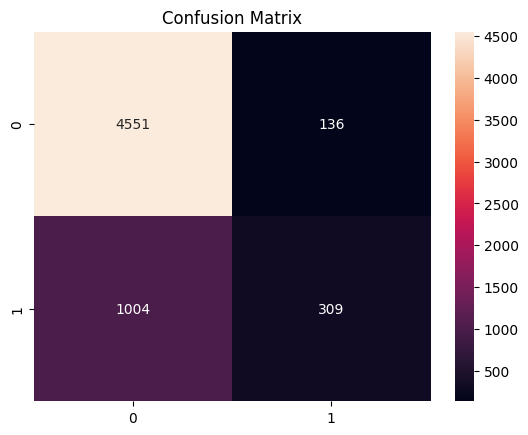

In [13]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

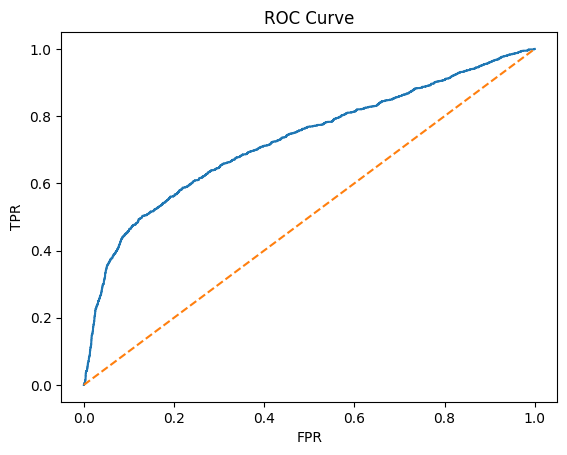

In [14]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

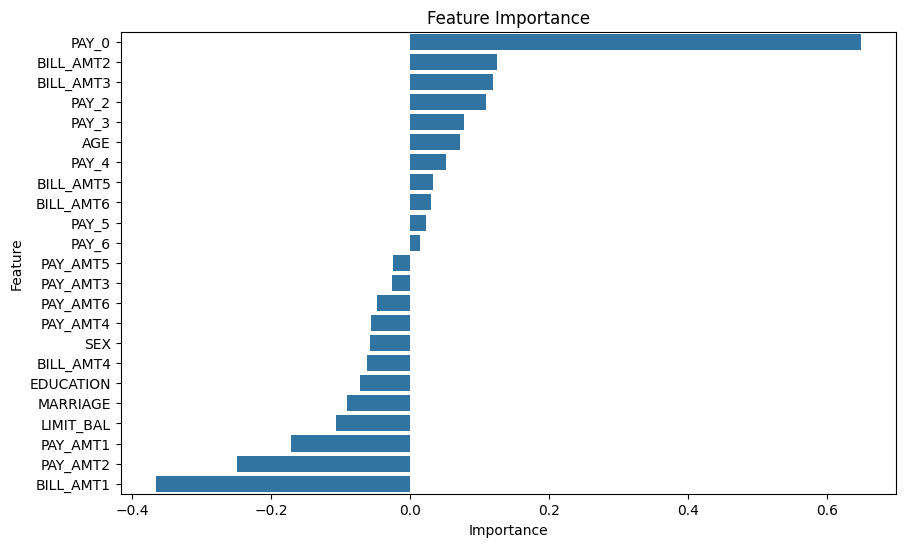

In [15]:
# coefficients
importance = pd.DataFrame({
    'Feature': df.drop('default', axis=1).columns,
    'Importance': model.coef_[0]
})

importance = importance.sort_values(by='Importance', ascending=False)

# plot
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance)
plt.title("Feature Importance")
plt.show()

In [16]:
from imblearn.over_sampling import SMOTE

# apply only on training data
sm = SMOTE(random_state=42)

X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print("Before SMOTE:\n", y_train.value_counts())
print("\nAfter SMOTE:\n", y_train_sm.value_counts())

Before SMOTE:
 default
0    18677
1     5323
Name: count, dtype: int64

After SMOTE:
 default
0    18677
1    18677
Name: count, dtype: int64


C:\Users\Anish\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Anish\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\Anish\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Anish\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\Anish\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreatePro

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_sm = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

In [18]:
from sklearn.linear_model import LogisticRegression

model_sm = LogisticRegression(max_iter=1000)

model_sm.fit(X_train_sm, y_train_sm)

# predictions
y_pred_sm = model_sm.predict(X_test_scaled)
y_prob_sm = model_sm.predict_proba(X_test_scaled)[:, 1]

In [19]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_sm))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_sm))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_sm))

Accuracy: 0.685
ROC-AUC: 0.7325068723248225

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.69      0.77      4687
           1       0.37      0.65      0.48      1313

    accuracy                           0.69      6000
   macro avg       0.63      0.67      0.63      6000
weighted avg       0.77      0.69      0.71      6000



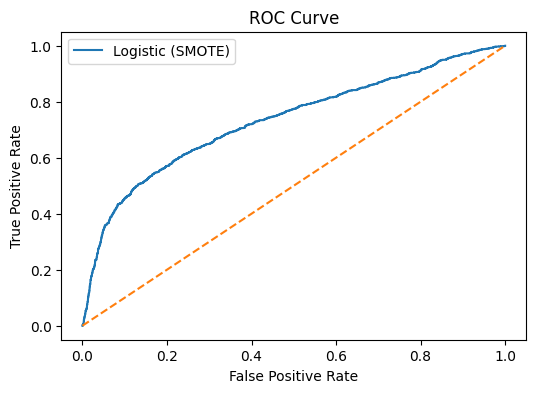

In [20]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_prob_sm)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label="Logistic (SMOTE)")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

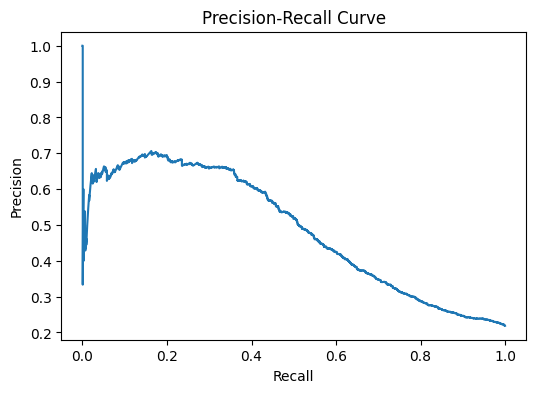

In [21]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob_sm)

plt.figure(figsize=(6,4))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [22]:
import numpy as np
from sklearn.metrics import classification_report

thresholds = np.arange(0.2, 0.6, 0.05)

for t in thresholds:
    y_pred_t = (y_prob_sm > t).astype(int)
    
    print(f"\n========== Threshold: {t} ==========")
    print(classification_report(y_test, y_pred_t))


========== Threshold: 0.2 ==========
              precision    recall  f1-score   support

           0       0.92      0.11      0.20      4687
           1       0.23      0.96      0.38      1313

    accuracy                           0.30      6000
   macro avg       0.58      0.54      0.29      6000
weighted avg       0.77      0.30      0.24      6000


========== Threshold: 0.25 ==========
              precision    recall  f1-score   support

           0       0.89      0.18      0.30      4687
           1       0.24      0.92      0.38      1313

    accuracy                           0.34      6000
   macro avg       0.57      0.55      0.34      6000
weighted avg       0.75      0.34      0.32      6000


========== Threshold: 0.3 ==========
              precision    recall  f1-score   support

           0       0.89      0.24      0.38      4687
           1       0.25      0.89      0.39      1313

    accuracy                           0.38      6000
   macro avg 

In [23]:
best_threshold = 0.35  # change based on your observation

y_pred_final = (y_prob_sm > best_threshold).astype(int)

print("Final Model Performance:\n")
print(classification_report(y_test, y_pred_final))

Final Model Performance:

              precision    recall  f1-score   support

           0       0.89      0.33      0.48      4687
           1       0.26      0.85      0.40      1313

    accuracy                           0.45      6000
   macro avg       0.58      0.59      0.44      6000
weighted avg       0.75      0.45      0.47      6000



In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

baseline_model = LogisticRegression(max_iter=1000)

baseline_model.fit(X_train, y_train)

y_prob_base = baseline_model.predict_proba(X_test)[:,1]

print("Baseline ROC-AUC:", roc_auc_score(y_test, y_prob_base))
print("SMOTE ROC-AUC:", roc_auc_score(y_test, y_prob_sm))

Baseline ROC-AUC: 0.7270980597920289
SMOTE ROC-AUC: 0.7325068723248225


In [29]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)  # NO SMOTE

y_prob_rf = rf.predict_proba(X_test)[:,1]

print("Random Forest ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Random Forest ROC-AUC: 0.7543711593263016


In [31]:
y_pred_rf = rf.predict(X_test)

print("Random Forest Classification Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4687
           1       0.64      0.36      0.46      1313

    accuracy                           0.82      6000
   macro avg       0.74      0.65      0.68      6000
weighted avg       0.80      0.82      0.80      6000



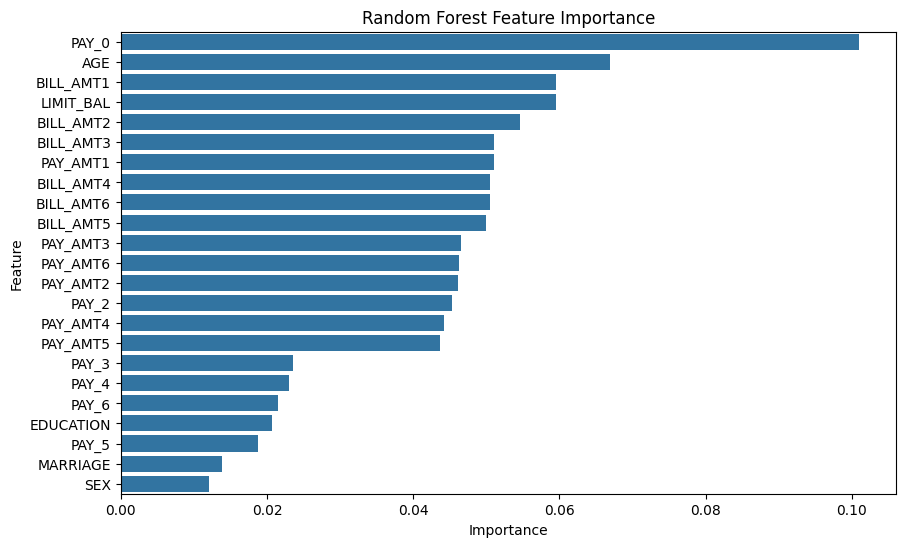

In [32]:
import pandas as pd
import seaborn as sns

importances = pd.DataFrame({
    'Feature': df.drop('default', axis=1).columns,
    'Importance': rf.feature_importances_
})

importances = importances.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importances)
plt.title("Random Forest Feature Importance")
plt.show()

In [34]:
print("\n===== MODEL COMPARISON =====")

print("Logistic (SMOTE) ROC-AUC:", roc_auc_score(y_test, y_prob_sm))
print("Random Forest ROC-AUC:", roc_auc_score(y_test, y_prob_rf))


===== MODEL COMPARISON =====
Logistic (SMOTE) ROC-AUC: 0.7325068723248225
Random Forest ROC-AUC: 0.7543711593263016


In [37]:
from xgboost import XGBClassifier

In [39]:
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=3,   # important for imbalance
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

C:\Users\Anish\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:37:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [40]:
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
y_pred_xgb = xgb.predict(X_test)

In [41]:
from sklearn.metrics import classification_report, roc_auc_score

print("XGBoost ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

print("\nXGBoost Classification Report:\n")
print(classification_report(y_test, y_pred_xgb))

XGBoost ROC-AUC: 0.7830252236298452

XGBoost Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.83      0.85      4687
           1       0.49      0.59      0.54      1313

    accuracy                           0.78      6000
   macro avg       0.69      0.71      0.69      6000
weighted avg       0.79      0.78      0.78      6000



In [42]:
print("\n===== MODEL COMPARISON =====")

print("Logistic (SMOTE) ROC-AUC:", roc_auc_score(y_test, y_prob_sm))
print("Random Forest ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("XGBoost ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))


===== MODEL COMPARISON =====
Logistic (SMOTE) ROC-AUC: 0.7325068723248225
Random Forest ROC-AUC: 0.7543711593263016
XGBoost ROC-AUC: 0.7830252236298452


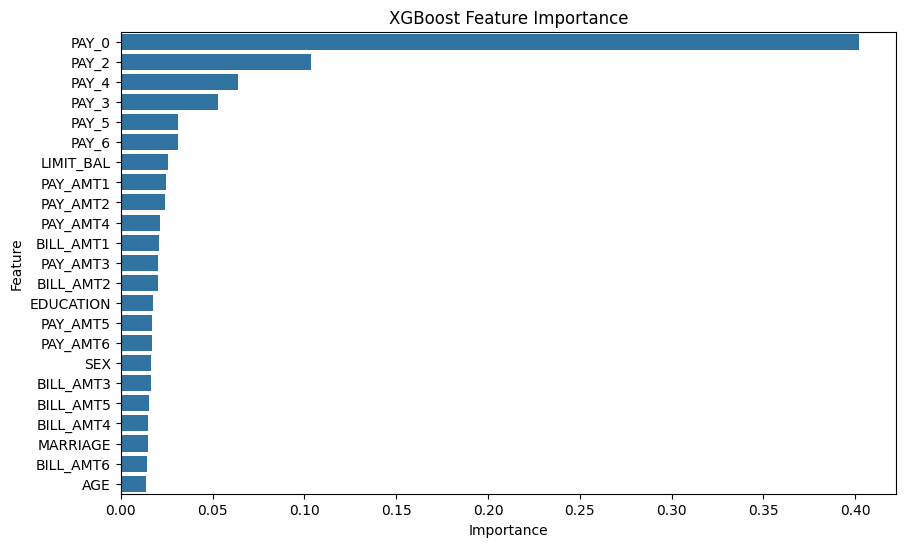

In [43]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

xgb_importance = pd.DataFrame({
    'Feature': df.drop('default', axis=1).columns,
    'Importance': xgb.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=xgb_importance)
plt.title("XGBoost Feature Importance")
plt.show()

In [44]:
import numpy as np

thresholds = np.arange(0.3, 0.7, 0.05)

for t in thresholds:
    y_pred_t = (y_prob_xgb > t).astype(int)
    
    print(f"\n========== Threshold: {t} ==========")
    print(classification_report(y_test, y_pred_t))


========== Threshold: 0.3 ==========
              precision    recall  f1-score   support

           0       0.91      0.53      0.67      4687
           1       0.33      0.82      0.47      1313

    accuracy                           0.59      6000
   macro avg       0.62      0.68      0.57      6000
weighted avg       0.79      0.59      0.63      6000


========== Threshold: 0.35 ==========
              precision    recall  f1-score   support

           0       0.90      0.64      0.75      4687
           1       0.37      0.75      0.50      1313

    accuracy                           0.67      6000
   macro avg       0.64      0.70      0.63      6000
weighted avg       0.79      0.67      0.70      6000


========== Threshold: 0.39999999999999997 ==========
              precision    recall  f1-score   support

           0       0.89      0.73      0.80      4687
           1       0.42      0.69      0.52      1313

    accuracy                           0.72      60

In [45]:
# FINAL MODEL (XGBoost with optimized threshold)

best_threshold = 0.45   # change if you prefer 0.5

y_pred_final_xgb = (y_prob_xgb > best_threshold).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print("Final XGBoost Model Performance:\n")
print(classification_report(y_test, y_pred_final_xgb))

Final XGBoost Model Performance:

              precision    recall  f1-score   support

           0       0.88      0.78      0.83      4687
           1       0.45      0.64      0.53      1313

    accuracy                           0.75      6000
   macro avg       0.67      0.71      0.68      6000
weighted avg       0.79      0.75      0.77      6000



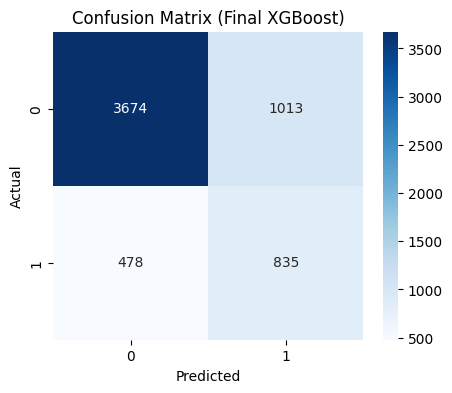

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_final_xgb)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Final XGBoost)")
plt.show()

In [61]:


results = pd.DataFrame({
    "Model": ["Logistic (SMOTE)", "Random Forest", "XGBoost"],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_sm),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

print(results)

              Model   ROC-AUC
0  Logistic (SMOTE)  0.732507
1     Random Forest  0.754371
2           XGBoost  0.783025


In [63]:
# STEP 1: Cross-validation (XGBoost)

from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_cv_scores = cross_val_score(
    xgb,
    X_train,
    y_train,
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1
)

print("Cross-validation ROC-AUC scores:", xgb_cv_scores)
print("Mean ROC-AUC:", xgb_cv_scores.mean())
print("Std Dev:", xgb_cv_scores.std())

Cross-validation ROC-AUC scores: [0.78997204 0.78068146 0.77548843 0.77937075 0.7820108 ]
Mean ROC-AUC: 0.7815046962430741
Std Dev: 0.004761907906278091


In [65]:
# STEP 2: Precision-Recall AUC

from sklearn.metrics import average_precision_score

pr_auc_xgb = average_precision_score(y_test, y_prob_xgb)

print("XGBoost Precision-Recall AUC:", pr_auc_xgb)

XGBoost Precision-Recall AUC: 0.5518084753424026


In [67]:
# STEP 3: Enhanced comparison table

results = pd.DataFrame({
    "Model": ["Logistic (SMOTE)", "Random Forest", "XGBoost"],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_sm),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ],
    "PR-AUC": [
        average_precision_score(y_test, y_prob_sm),
        average_precision_score(y_test, y_prob_rf),
        average_precision_score(y_test, y_prob_xgb)
    ]
})

print(results)

              Model   ROC-AUC    PR-AUC
0  Logistic (SMOTE)  0.732507  0.486605
1     Random Forest  0.754371  0.513685
2           XGBoost  0.783025  0.551808


In [69]:
# STEP 4: Cost-based evaluation

from sklearn.metrics import confusion_matrix

# define business costs
cost_fn = 10   # missing a defaulter
cost_fp = 1    # false alarm

cm = confusion_matrix(y_test, y_pred_final)

tn, fp, fn, tp = cm.ravel()

total_cost = fn * cost_fn + fp * cost_fp

print("Confusion Matrix:", cm)
print("Total Cost:", total_cost)

Confusion Matrix: [[3674 1013]
 [ 478  835]]
Total Cost: 5793


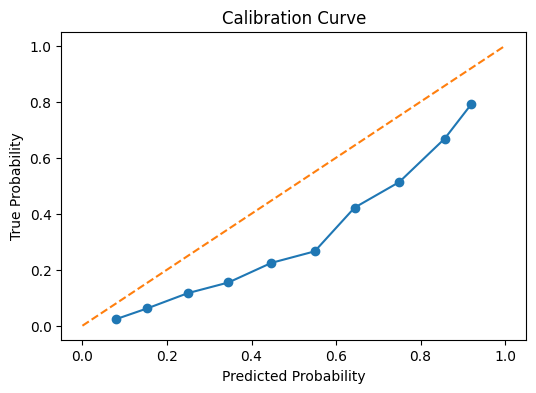

In [71]:
# STEP 5: Calibration curve

from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(y_test, y_prob_xgb, n_bins=10)

plt.figure(figsize=(6,4))
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.title("Calibration Curve")
plt.show()

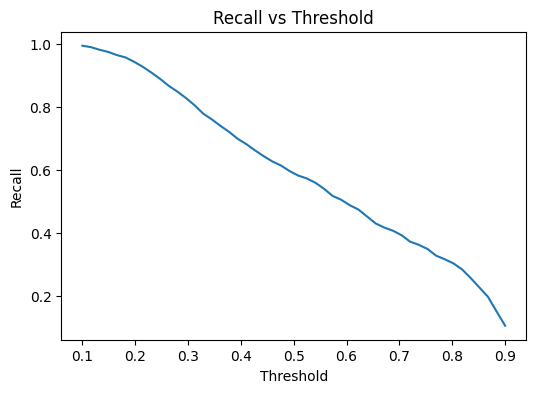

In [73]:
# STEP 6: Threshold vs Recall

import numpy as np

thresholds = np.linspace(0.1, 0.9, 50)
recalls = []

for t in thresholds:
    y_pred_t = (y_prob_xgb > t).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm.ravel()
    recall = tp / (tp + fn)
    recalls.append(recall)

plt.figure(figsize=(6,4))
plt.plot(thresholds, recalls)
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.title("Recall vs Threshold")
plt.show()

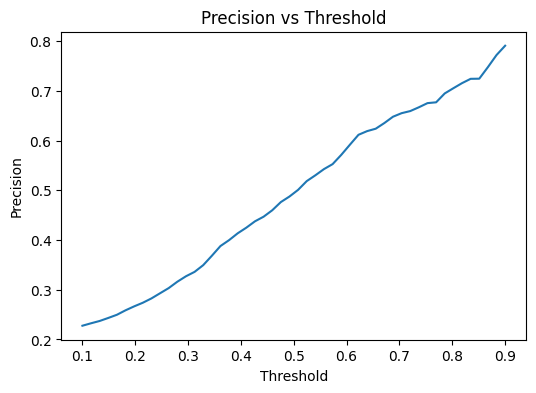

In [75]:
# STEP 7: Threshold vs Precision

precisions = []

for t in thresholds:
    y_pred_t = (y_prob_xgb > t).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    precisions.append(precision)

plt.figure(figsize=(6,4))
plt.plot(thresholds, precisions)
plt.xlabel("Threshold")
plt.ylabel("Precision")
plt.title("Precision vs Threshold")
plt.show()

In [77]:
# STEP 8: Hyperparameter tuning (XGBoost)

from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200],
}

grid = GridSearchCV(
    XGBClassifier(
        random_state=42,
        scale_pos_weight=3,
        use_label_encoder=False,
        eval_metric='logloss'
    ),
    param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best CV Score: 0.7809831426140149


C:\Users\Anish\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:52:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [79]:
# STEP 9: Final tuned model

best_xgb = grid.best_estimator_

y_prob_best = best_xgb.predict_proba(X_test)[:,1]

print("Tuned XGBoost ROC-AUC:", roc_auc_score(y_test, y_prob_best))

Tuned XGBoost ROC-AUC: 0.7818983199792137


In [81]:
# STEP: Statistical significance (paired t-test)

from scipy.stats import ttest_rel

# cross-val scores for models
log_cv = cross_val_score(LogisticRegression(max_iter=1000), X_train, y_train, cv=5, scoring='roc_auc')
rf_cv = cross_val_score(rf, X_train, y_train, cv=5, scoring='roc_auc')
xgb_cv = cross_val_score(xgb, X_train, y_train, cv=5, scoring='roc_auc')

# compare XGB vs RF
t_stat, p_val = ttest_rel(xgb_cv, rf_cv)

print("T-statistic:", t_stat)
print("P-value:", p_val)

C:\Users\Anish\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:00:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Anish\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:00:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Anish\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:00:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Anish\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:00:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtr

T-statistic: 13.351010788040014
P-value: 0.00018198008046402993


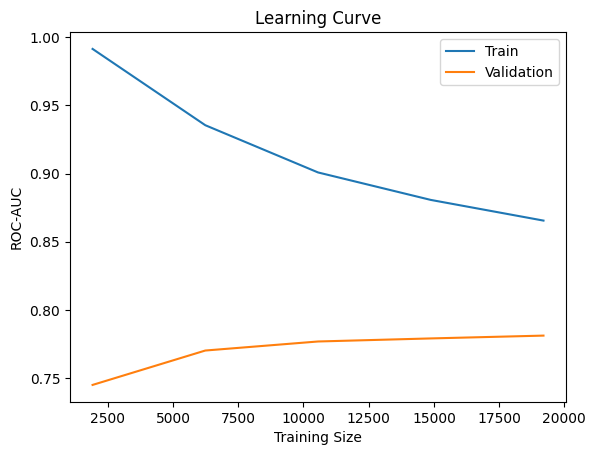

In [83]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    xgb, X_train, y_train,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

plt.plot(train_sizes, train_scores.mean(axis=1), label="Train")
plt.plot(train_sizes, val_scores.mean(axis=1), label="Validation")
plt.xlabel("Training Size")
plt.ylabel("ROC-AUC")
plt.title("Learning Curve")
plt.legend()
plt.show()

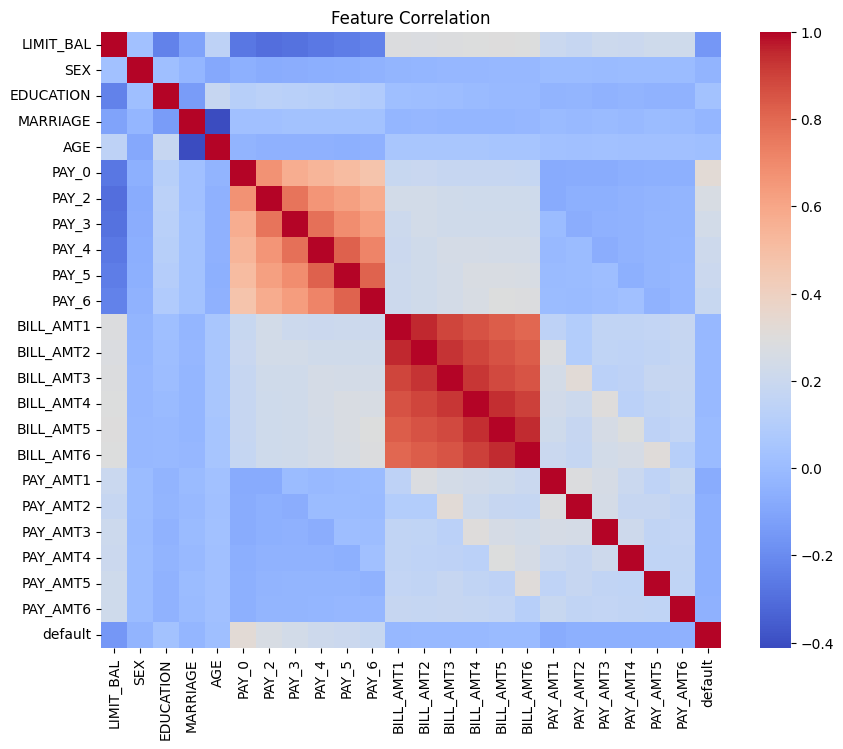

In [85]:
import seaborn as sns

# correlation matrix
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

In [87]:
# model stability across seeds

seeds = [0, 42, 100, 200]
scores = []

for s in seeds:
    model = XGBClassifier(random_state=s, scale_pos_weight=3, eval_metric='logloss')
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:,1]
    scores.append(roc_auc_score(y_test, y_prob))

print("ROC-AUC across seeds:", scores)
print("Std deviation:", np.std(scores))

ROC-AUC across seeds: [0.765873457576018, 0.765873457576018, 0.765873457576018, 0.765873457576018]
Std deviation: 0.0


In [89]:
# rank customers by risk

risk_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted_Prob": y_prob_xgb
})

risk_df = risk_df.sort_values(by="Predicted_Prob", ascending=False)

print(risk_df.head(10))

       Actual  Predicted_Prob
17239       1        0.957211
14950       1        0.955392
17756       1        0.955070
14244       1        0.954195
20721       1        0.953284
15947       1        0.950772
28851       1        0.949539
1751        1        0.947882
10124       0        0.945930
29500       1        0.943779


In [91]:
# decile analysis

risk_df['Decile'] = pd.qcut(risk_df['Predicted_Prob'], 10, labels=False)

decile_default_rate = risk_df.groupby('Decile')['Actual'].mean()

print(decile_default_rate)

Decile
0    0.041667
1    0.053333
2    0.106667
3    0.113333
4    0.150000
5    0.131667
6    0.215000
7    0.250000
8    0.431667
9    0.695000
Name: Actual, dtype: float64
